# Digit Recognizer

## Import External Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import seaborn as sns
import sklearn

%matplotlib inline

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

## Data Preperation

### Import CSV Files

In [2]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

print(f"The shape of the training set is: {train_data.shape}")
print(f"The shape of the test set is: {test_data.shape}")

The shape of the training set is: (42000, 785)
The shape of the test set is: (28000, 784)


### Splitting the Training Data

In [3]:
Y_train = train_data["label"]
X_train = train_data.drop(labels = ["label"], axis = 1)

Y_train.value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

Notes to turn into paragraph:
- Data loads properly
- Some observations that are made
- Make a graph
- Describe graph

### Checking for Missing Data

In [4]:
X_train.isnull().any().describe()

count       784
unique        1
top       False
freq        784
dtype: object

In [5]:
test_data.isnull().any().describe()

count       784
unique        1
top       False
freq        784
dtype: object

Notes to turn into paragraph:
- No missing data
- Reduces the stress on the AI
- No corrupted imagers

### Normalization

In [6]:
X_train = X_train / 255.0
test_data = test_data / 255.0

Notes on normalization: 
- 255 being absolute white
- makes values between 0 and 1
- faster convergence
- equal treatment

### Reshape

In [7]:
X_train = X_train.values.reshape(-1, 28, 28, 1)
test_data = test_data.values.reshape(-1, 28, 28, 1)

Notes on reshaping to turn into paragraph:
- -1 batch size, 28, height, 28 width, 1 channels
- batch size tells numpy to calculate how many images are in the dataset
- height and with are the pixel count of a standard MNIST digit
- channels is representative of the color depth which is in grayscale so its 0-1
- .values extracts raw underlying NumPy array from DataFrame

### Label Encoding

In [8]:
Y_train = to_categorical(Y_train, num_classes=10)

Notes on label encoding to turn into paragraph:
- integer labels are a problem as one is worth more or greater than another
- We needed distinct buckets
- Used One-Hot encoding

### Splitting Into Training and Validation Set

In [9]:
random_seed = 2

In [10]:
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = 0.1, random_state=random_seed)

Notes on splitting the dataset to turn into paragraph:
- A model might achieve 99% accuracy on the training set but 60-70% on the validation set (memorization)
- Helps the model realize its errors
- Why we split it specifically
- What is random seed

## Convolutional Neural Network

### Defining the Model

In [11]:
model = Sequential()
# model.add(Conv2D(filters=32, kernel_size=(5,5), padding = 'Same', activation='relu', input_shape=(28,28,1)))
model.add(Conv2D(32, (5,5), activation = 'relu', padding = 'Same', input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (5,5), padding = 'Same', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (5,5), padding = 'Same', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

/Users/conradmutai/.pyenv/versions/jupyter-py312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,794 (1.55 MB)

 Trainable params: 406,346 (1.55 MB)

 Non-trainable params: 448 (1.75 KB)

Notes on defining model to turn into paragraph:
- talk about why i did this
- discuss the kernel sizes
- how it works
- why i used a dropout
- why a cnn

### Optimizers and Annealers

In [13]:
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

In [14]:
epochs = 30
batch_size = 64

In [15]:
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', patience = 5, factor = 0.5, min_lr = 0.00001)

Notes on optimizers to turn into paragraph:
- why i chose adam
- discuss the loss model
- and why the metrics was chosen
- why i chose this amount of epochs
- why i chose this batch size
- explain annealer
- why the patience is 3 and how it is related to the epochs
- explain the meaning of factor 0.5
- explain why min_lr = 0.0001 and how it allows the model to keep learning

### Data Augmentation

In [16]:
datagen = ImageDataGenerator(
    rotation_range = 10,
    zoom_range = 0.1,
    width_shift_range = 0.1, 
    height_shift_range = 0.1
)

datagen.fit(X_train)

### Fitting the Model

In [17]:
history = model.fit(
    datagen.flow(X_train, Y_train, batch_size = batch_size),
    epochs = epochs,
    validation_data = (X_val, Y_val),
    callbacks = reduce_lr
)

Epoch 1/30


/Users/conradmutai/.pyenv/versions/jupyter-py312/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


591/591 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7249 - loss: 0.8868 - val_accuracy: 0.9814 - val_loss: 0.0597 - learning_rate: 0.0010
Epoch 2/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9596 - loss: 0.1504 - val_accuracy: 0.9879 - val_loss: 0.0434 - learning_rate: 0.0010
Epoch 3/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9715 - loss: 0.1067 - val_accuracy: 0.9893 - val_loss: 0.0395 - learning_rate: 0.0010
Epoch 4/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9757 - loss: 0.0902 - val_accuracy: 0.9871 - val_loss: 0.0421 - learning_rate: 0.0010
Epoch 5/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9782 - loss: 0.0792 - val_accuracy: 0.9867 - val_loss: 0.0492 - learning_rate: 0.0010
Epoch 6/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9815 - loss: 0.0641 - val_accuracy: 0.9883 - val_loss: 0.0510 - learning_rate: 0.0010
Epoch 7/30
591/591 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9838 - loss: 0.0602

## Data Analysis

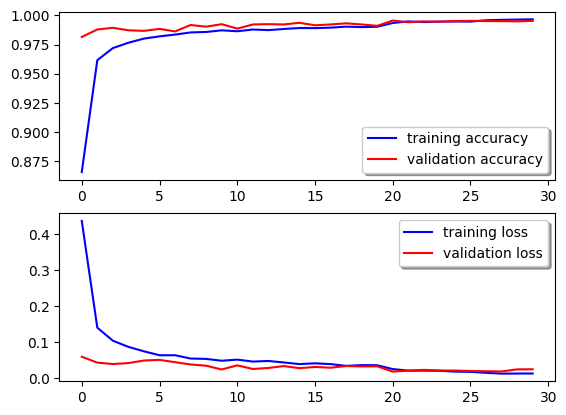

In [18]:
fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['accuracy'], label = 'training accuracy', color = 'b')
ax[0].plot(history.history['val_accuracy'], label = 'validation accuracy', color = 'r')
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['loss'], label = 'training loss', color = 'b')
ax[1].plot(history.history['val_loss'], label = 'validation loss', color = 'r')
legend = ax[1].legend(loc='best', shadow=True)

Notes on the fitting of the model and model accuracy:
- the model accuracy
- why i did what i did
- explain the graph

In [19]:
# get raw probabilities
Y_pred_probs = model.predict(X_val)
# convert the classes back into integer values
Y_pred_classes = np.argmax(Y_pred_probs, axis = 1)
# Convert the One-Hot encoded validation labels back to single integers
Y_true = np.argmax(Y_val, axis = 1)

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [20]:
confusion_matrix = confusion_matrix(Y_true, Y_pred_classes)

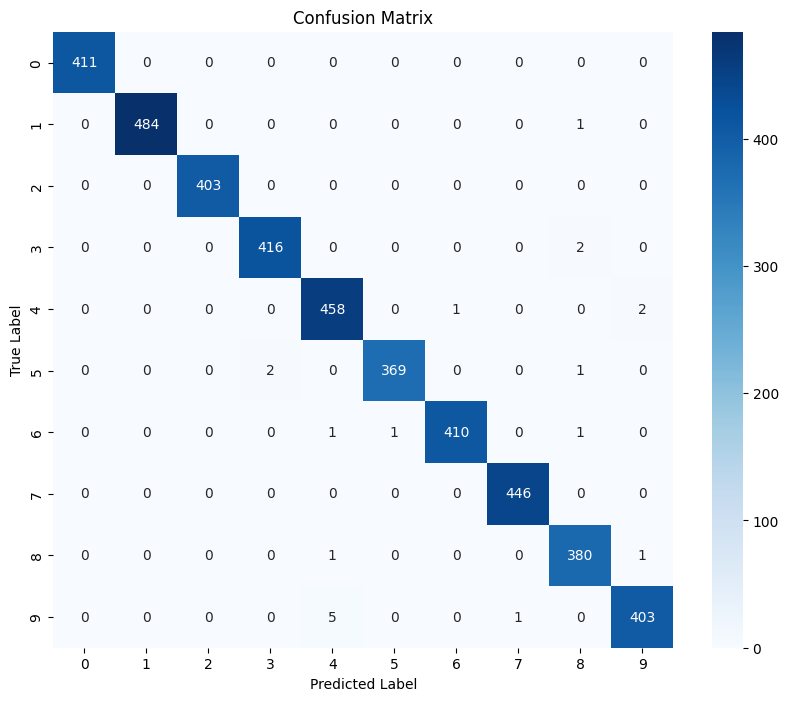

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

### Errors

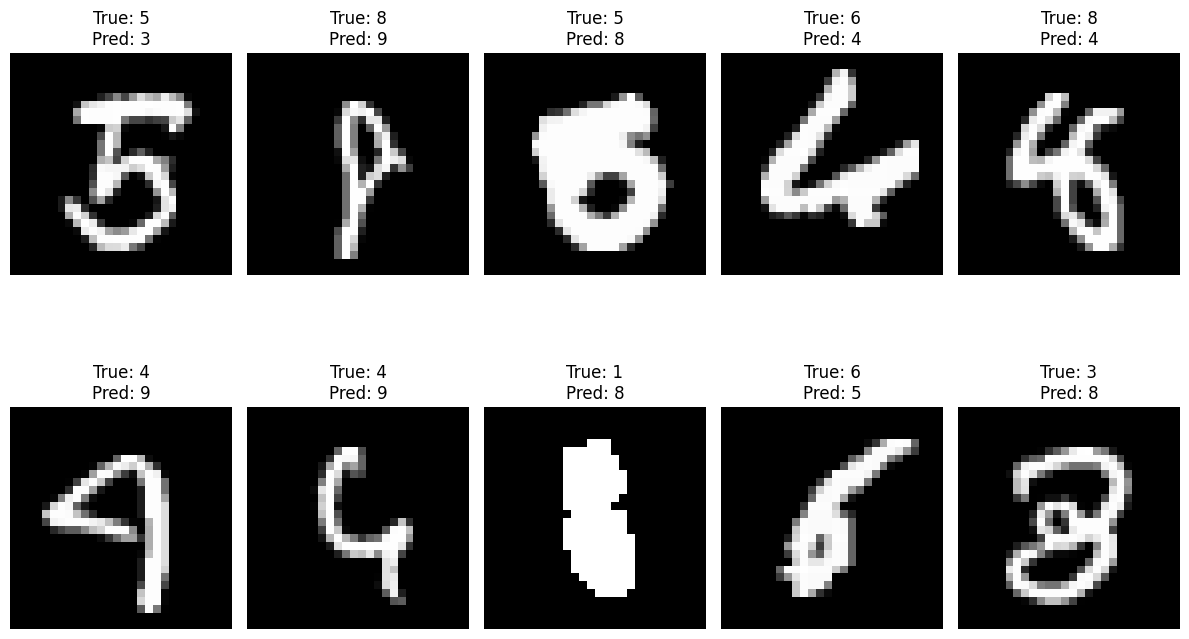

In [22]:
errors = (Y_pred_classes - Y_true != 0)

Y_pred_classes_errors = Y_pred_classes[errors]
Y_pred_errors = Y_pred_probs[errors]
Y_true_errors = Y_true[errors]
X_val_errors = X_val[errors]

# Plot the first 10 errors
plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_val_errors[i].reshape(28,28), cmap='gray')
    plt.title(f"True: {Y_true_errors[i]}\nPred: {Y_pred_classes_errors[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [23]:
results = model.predict(test_data)
results = np.argmax(results, axis=1)
results = pd.Series(results, name="Label")

875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [24]:
submission = pd.concat([pd.Series(range(1, 28001), name="ImageId"), results], axis=1)
submission.to_csv("cnn_mnist_submission.csv", index=False)
print("Submission file 'cnn_mnist_submission.csv' has been created!")

Submission file 'cnn_mnist_submission.csv' has been created!
